In [1]:
TRAIN_DIR = "EuroSAT_Dataset/EuroSAT/train"
VAL_DIR = "EuroSAT_Dataset/EuroSAT/val"
TEST_DIR = "EuroSAT_Dataset/EuroSAT_test_flat"

In [2]:
import os
import random
import numpy as np
import pandas as pd

from PIL import Image

import torch
import torch.nn as nn

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from torchvision import transforms
from torchvision.models import densenet121

from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

In [3]:
IMG_SIZE = 224

BATCH_SIZE = 64

EPOCHS = 20

LR = 0.001

SEED = 42

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

Device: cuda


In [4]:
def seed_everything(seed=42):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

In [5]:
CLASS_NAMES = sorted(
    os.listdir(TRAIN_DIR)
)

CLASS_TO_IDX = {
    cls:i
    for i, cls in enumerate(CLASS_NAMES)
}

IDX_TO_CLASS = {
    i:cls
    for cls, i in CLASS_TO_IDX.items()
}

NUM_CLASSES = len(CLASS_NAMES)

print(CLASS_NAMES)
print(NUM_CLASSES)

['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
10


In [6]:
train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomVerticalFlip(),

    # transforms.RandomRotation(20),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

val_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [7]:
class EuroSATDataset(Dataset):

    def __init__(
            self,
            root_dir,
            transform=None):

        self.root_dir = root_dir

        self.transform = transform

        self.samples = []

        for cls_name in sorted(os.listdir(root_dir)):

            cls_path = os.path.join(
                root_dir,
                cls_name
            )

            if not os.path.isdir(cls_path):
                continue

            label = CLASS_TO_IDX[cls_name]

            for file in os.listdir(cls_path):

                if file.endswith(
                    (".jpg",
                     ".jpeg",
                     ".png")
                ):

                    self.samples.append(

                        (
                            os.path.join(
                                cls_path,
                                file
                            ),
                            label
                        )
                    )

    def __len__(self):

        return len(self.samples)

    def __getitem__(self, idx):

        img_path, label = self.samples[idx]

        image = Image.open(
            img_path
        ).convert("RGB")

        if self.transform:

            image = self.transform(image)

        return image, label

In [8]:
class EuroSATTestDataset(Dataset):

    def __init__(
            self,
            root_dir,
            transform=None):

        self.root_dir = root_dir

        self.transform = transform

        self.images = sorted(

            [
                f for f in os.listdir(root_dir)
                if f.endswith(
                    (
                        ".jpg",
                        ".jpeg",
                        ".png"
                    )
                )
            ]
        )

    def __len__(self):

        return len(self.images)

    def __getitem__(self, idx):

        img_name = self.images[idx]

        img_path = os.path.join(
            self.root_dir,
            img_name
        )

        image = Image.open(
            img_path
        ).convert("RGB")

        if self.transform:

            image = self.transform(image)

        return image, img_name

In [9]:
train_dataset = EuroSATDataset(
    TRAIN_DIR,
    train_transform
)

val_dataset = EuroSATDataset(
    VAL_DIR,
    val_transform
)

test_dataset = EuroSATTestDataset(
    TEST_DIR,
    val_transform
)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 18900
Val: 4050
Test: 4050


In [10]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    # num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    # num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    # num_workers=0,
    pin_memory=True
)

In [11]:
def show_samples(dataset):

    fig, axes = plt.subplots(
        3,
        5,
        figsize=(15,10)
    )

    axes = axes.flatten()

    for ax in axes:

        idx = random.randint(
            0,
            len(dataset)-1
        )

        image, label = dataset[idx]

        image = image.permute(
            1,
            2,
            0
        ).numpy()

        image = image * np.array(
            [0.229,0.224,0.225]
        ) + np.array(
            [0.485,0.456,0.406]
        )

        image = np.clip(
            image,
            0,
            1
        )

        ax.imshow(image)

        ax.set_title(
            IDX_TO_CLASS[label]
        )

        ax.axis("off")

    plt.tight_layout()

    plt.show()

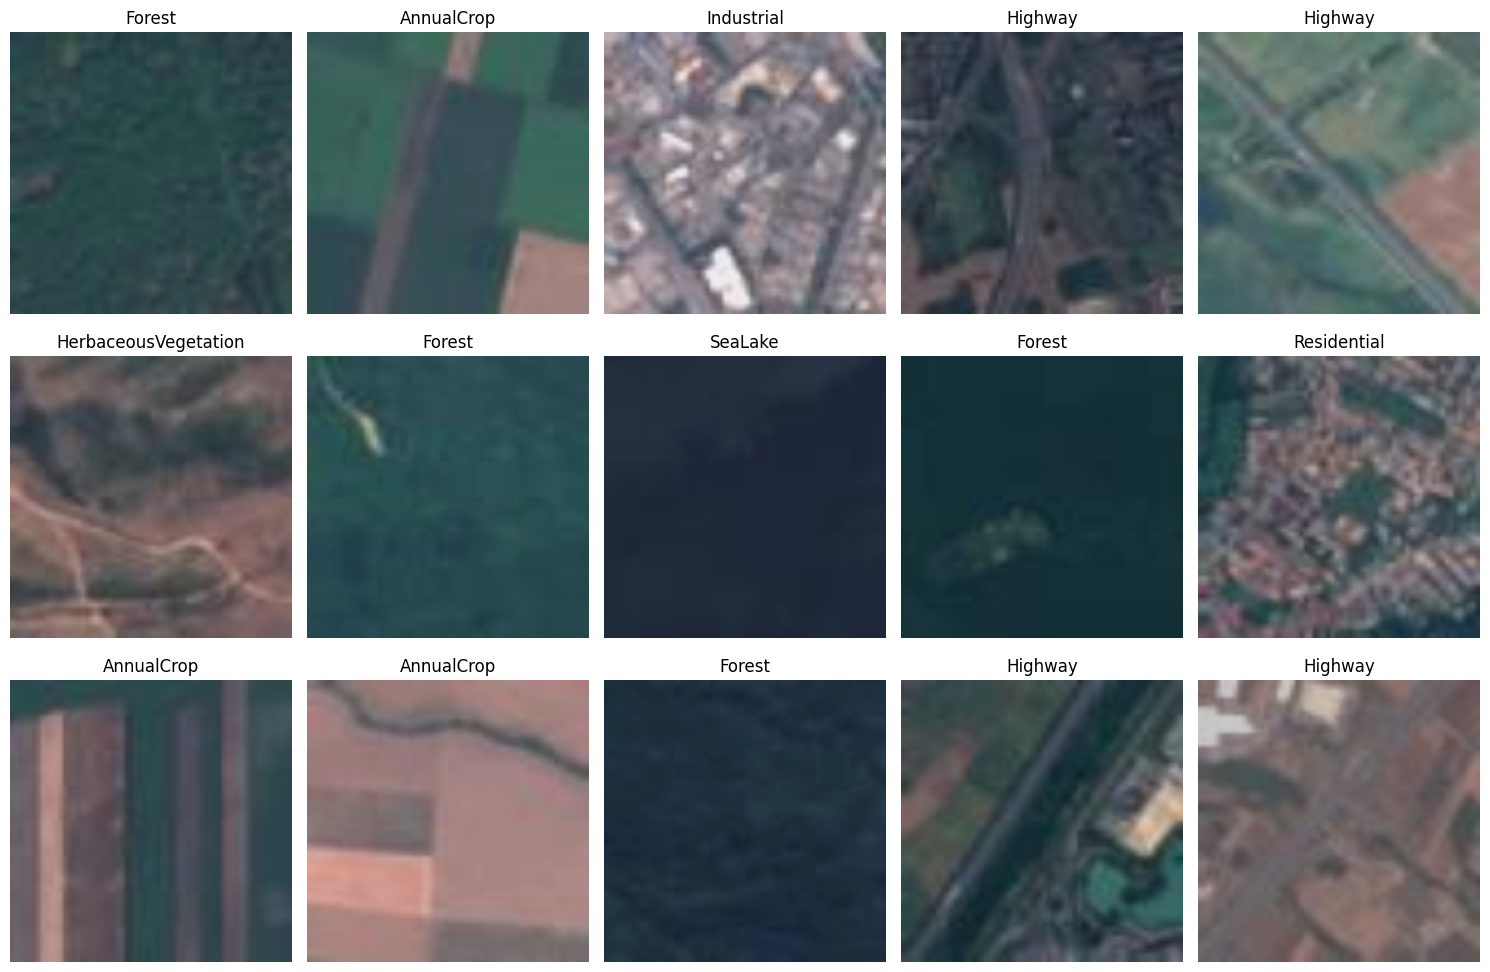

In [12]:
show_samples(train_dataset)

## Densenet model

In [13]:
model = densenet121(
    weights="DEFAULT"
)

in_features = model.classifier.in_features

model.classifier = nn.Linear(
    in_features,
    NUM_CLASSES
)

model = model.to(DEVICE)

print(model)

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, bias=T

In [14]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

In [15]:
def train_one_epoch(
        model,
        loader,
        criterion,
        optimizer,
        device):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    pbar = tqdm(
        loader,
        desc="Training",
        leave=False
    )

    for images, labels in pbar:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        preds = outputs.argmax(1)

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": f"{100*correct/total:.2f}%"
        })

    epoch_loss = running_loss / len(loader)

    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

In [16]:
@torch.no_grad()
def validate(
        model,
        loader,
        criterion,
        device):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    pbar = tqdm(
        loader,
        desc="Validation",
        leave=False
    )

    for images, labels in pbar:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        running_loss += loss.item()

        preds = outputs.argmax(1)

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / len(loader)

    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

In [17]:
history = {

    "train_loss": [],
    "val_loss": [],

    "train_acc": [],
    "val_acc": []
}

In [18]:
best_val_acc = 0

for epoch in range(EPOCHS):

    print(
        f"\nEpoch {epoch+1}/{EPOCHS}"
    )

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    scheduler.step()

    history["train_loss"].append(
        train_loss
    )

    history["val_loss"].append(
        val_loss
    )

    history["train_acc"].append(
        train_acc
    )

    history["val_acc"].append(
        val_acc
    )

    print(
        f"Train Loss: {train_loss:.4f}"
    )

    print(
        f"Train Acc : {train_acc:.2f}%"
    )

    print(
        f"Val Loss   : {val_loss:.4f}"
    )

    print(
        f"Val Acc    : {val_acc:.2f}%"
    )

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            "best_densenet121.pth"
        )

        print(
            "Best Model Saved"
        )


Epoch 1/20


Training:   0%|          | 0/296 [00:00<?, ?it/s]

Validation:   0%|          | 0/64 [00:00<?, ?it/s]

Train Loss: 0.4039
Train Acc : 86.46%
Val Loss   : 0.2844
Val Acc    : 90.57%
Best Model Saved

Epoch 2/20


Training:   0%|          | 0/296 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/64 [00:00<?, ?it/s]

Train Loss: 0.0116
Train Acc : 99.72%
Val Loss   : 0.0547
Val Acc    : 98.15%
Best Model Saved

Epoch 20/20


Training:   0%|          | 0/296 [00:00<?, ?it/s]

Validation:   0%|          | 0/64 [00:00<?, ?it/s]

Train Loss: 0.0093
Train Acc : 99.80%
Val Loss   : 0.0565
Val Acc    : 98.02%


In [19]:
model.load_state_dict(

    torch.load(
        "best_densenet121.pth",
        map_location=DEVICE
    )
)

model.eval()

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, bias=T

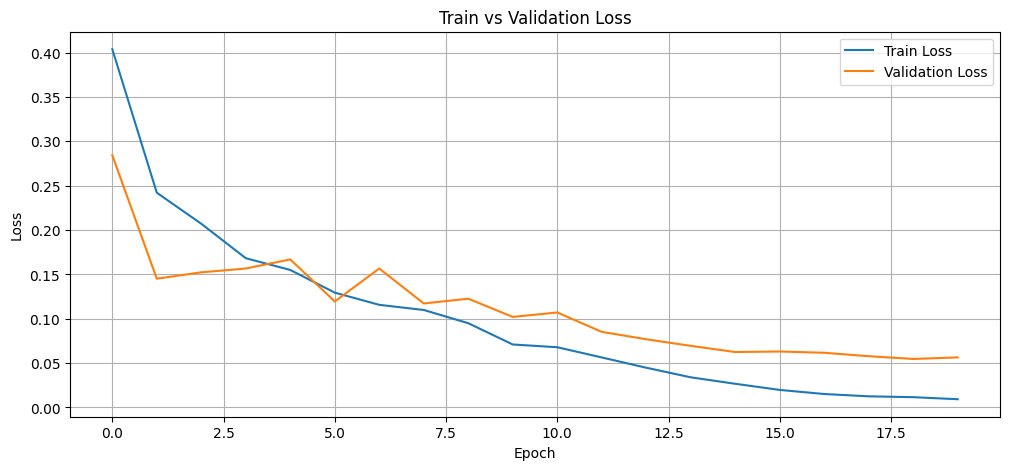

In [20]:
plt.figure(figsize=(12,5))

plt.plot(
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "Train vs Validation Loss"
)

plt.legend()

plt.grid()

plt.show()

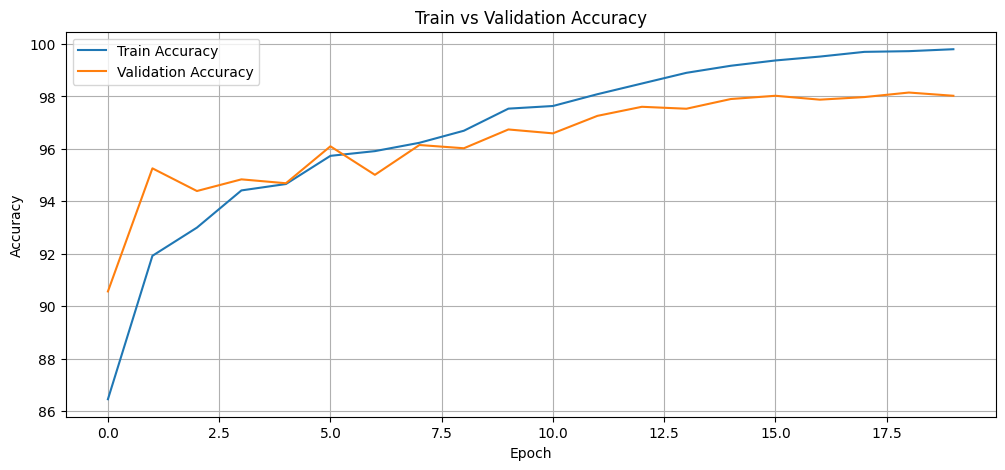

In [21]:
plt.figure(figsize=(12,5))

plt.plot(
    history["train_acc"],
    label="Train Accuracy"
)

plt.plot(
    history["val_acc"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title(
    "Train vs Validation Accuracy"
)

plt.legend()

plt.grid()

plt.show()

In [22]:
y_true = []

y_pred = []

model.eval()

with torch.no_grad():

    for images, labels in tqdm(val_loader):

        images = images.to(
            DEVICE
        )

        outputs = model(
            images
        )

        preds = outputs.argmax(
            1
        )

        y_true.extend(
            labels.numpy()
        )

        y_pred.extend(
            preds.cpu().numpy()
        )

  0%|          | 0/64 [00:00<?, ?it/s]

In [23]:
print(

    classification_report(

        y_true,

        y_pred,

        target_names=CLASS_NAMES

    )
)

                      precision    recall  f1-score   support

          AnnualCrop       0.98      0.98      0.98       450
              Forest       0.99      0.99      0.99       450
HerbaceousVegetation       0.96      0.98      0.97       450
             Highway       0.98      0.99      0.99       375
          Industrial       0.99      0.98      0.99       375
             Pasture       0.99      0.97      0.98       300
       PermanentCrop       0.95      0.96      0.96       375
         Residential       1.00      0.99      0.99       450
               River       0.98      0.98      0.98       375
             SeaLake       1.00      0.99      0.99       450

            accuracy                           0.98      4050
           macro avg       0.98      0.98      0.98      4050
        weighted avg       0.98      0.98      0.98      4050



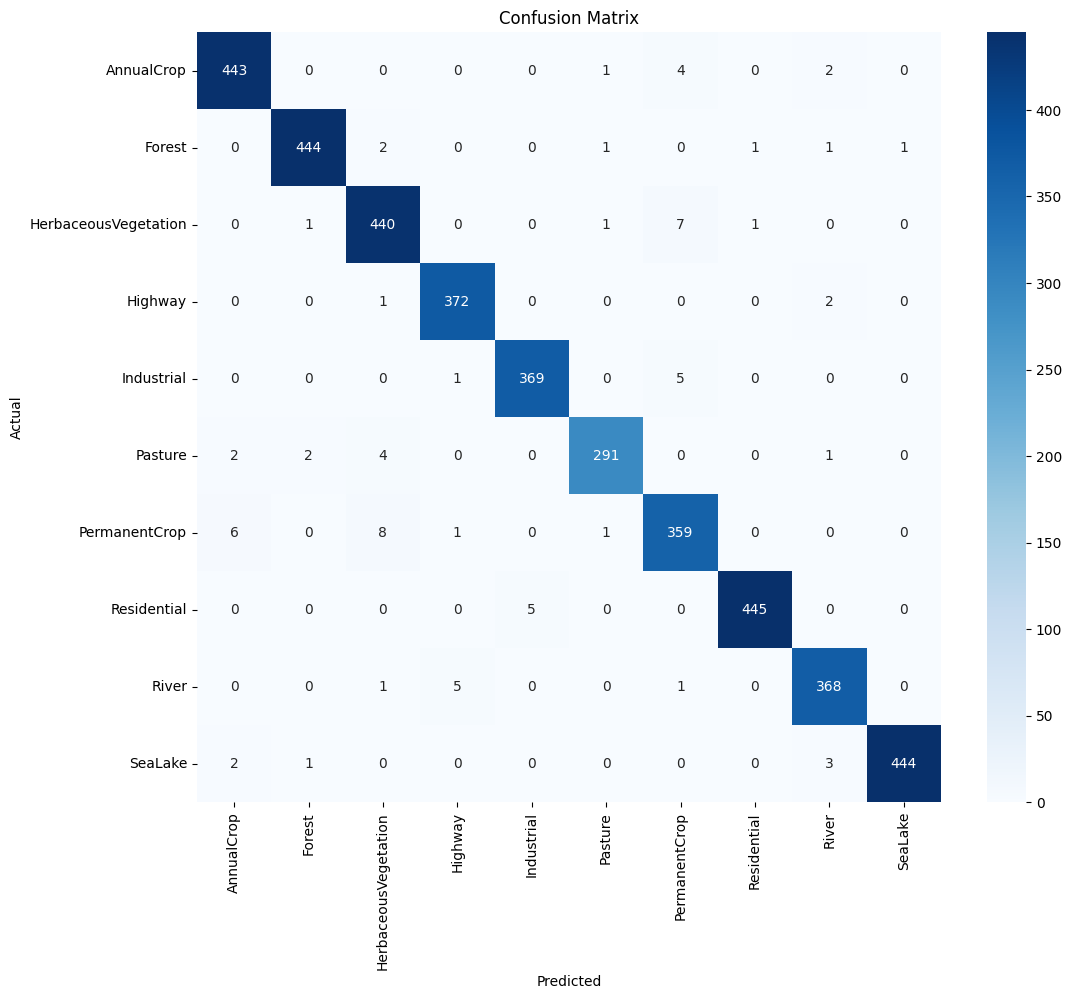

In [24]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(
    figsize=(12,10)
)

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=CLASS_NAMES,

    yticklabels=CLASS_NAMES
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "Confusion Matrix"
)

plt.show()

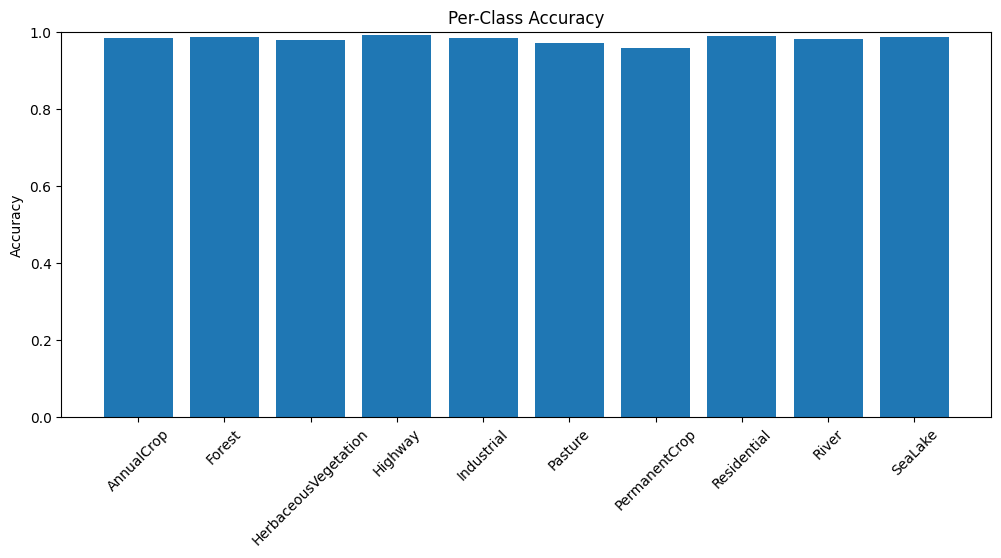

In [25]:
class_accuracy = (

    cm.diagonal()

    /

    cm.sum(axis=1)

)

plt.figure(
    figsize=(12,5)
)

plt.bar(

    CLASS_NAMES,

    class_accuracy
)

plt.xticks(
    rotation=45
)

plt.ylim(
    [0,1]
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "Per-Class Accuracy"
)

plt.show()

In [26]:
from torchinfo import summary

summary(

    model,

    input_size=(

        BATCH_SIZE,

        3,

        224,

        224

    )
)

Layer (type:depth-idx)                   Output Shape              Param #
DenseNet                                 [64, 10]                  --
├─Sequential: 1-1                        [64, 1024, 7, 7]          --
│    └─Conv2d: 2-1                       [64, 64, 112, 112]        9,408
│    └─BatchNorm2d: 2-2                  [64, 64, 112, 112]        128
│    └─ReLU: 2-3                         [64, 64, 112, 112]        --
│    └─MaxPool2d: 2-4                    [64, 64, 56, 56]          --
│    └─_DenseBlock: 2-5                  [64, 256, 56, 56]         --
│    │    └─_DenseLayer: 3-1             [64, 32, 56, 56]          45,440
│    │    └─_DenseLayer: 3-2             [64, 32, 56, 56]          49,600
│    │    └─_DenseLayer: 3-3             [64, 32, 56, 56]          53,760
│    │    └─_DenseLayer: 3-4             [64, 32, 56, 56]          57,920
│    │    └─_DenseLayer: 3-5             [64, 32, 56, 56]          62,080
│    │    └─_DenseLayer: 3-6             [64, 32, 56, 56]    

In [27]:
predictions = []

model.eval()

with torch.no_grad():

    for images, names in tqdm(
            test_loader):

        images = images.to(
            DEVICE
        )

        outputs = model(
            images
        )

        probs = torch.softmax(
            outputs,
            dim=1
        )

        confs, preds = probs.max(1)

        for name, pred, conf in zip(

                names,

                preds.cpu(),

                confs.cpu()):

            predictions.append(

                [

                    name,

                    IDX_TO_CLASS[
                        pred.item()
                    ],

                    conf.item()

                ]
            )

  0%|          | 0/64 [00:00<?, ?it/s]

In [28]:
submission = pd.DataFrame(

    predictions,

    columns=[

        "image_name",

        "predicted_class",

        "confidence"

    ]
)

submission.to_csv(

    "test_predictions.csv",

    index=False
)

submission.head()

,image_name,predicted_class,confidence
0,test_1.jpg,AnnualCrop,0.999795
1,test_10.jpg,AnnualCrop,0.999893
2,test_100.jpg,AnnualCrop,1.000000
3,test_1000.jpg,HerbaceousVegetation,0.999967
4,test_1001.jpg,HerbaceousVegetation,0.997742


In [29]:
submission = submission.sort_values(
    by="confidence",
    ascending=False
)

submission.head(20)

,image_name,predicted_class,confidence
4021,test_973.jpg,HerbaceousVegetation,1.0
32,test_1027.jpg,HerbaceousVegetation,1.0
4049,test_999.jpg,HerbaceousVegetation,1.0
4032,test_983.jpg,HerbaceousVegetation,1.0
30,test_1025.jpg,HerbaceousVegetation,1.0
2562,test_3304.jpg,River,1.0
3448,test_457.jpg,Forest,1.0
3433,test_443.jpg,AnnualCrop,1.0
844,test_1759.jpg,Industrial,1.0
852,test_1766.jpg,Industrial,1.0


In [30]:
torch.save(

    {

        "model_state_dict":
        model.state_dict(),

        "class_names":
        CLASS_NAMES

    },

    "DenseNet121_EuroSAT_RGB.pth"
)

print(
    "Model Saved Successfully"
)

Model Saved Successfully
